Q6 dataset shape: (5640, 8)

Detected 475 outliers out of 5640 samples.

Class distribution among outliers:
planet_class
Gas Giant       353
Super-Earth      51
Neptune-like     41
Terrestrial      30
Name: count, dtype: int64

First 10 detected outliers (features + class):
    pl_orbeccen  pl_eqt  st_logg  sy_pnum  log_pl_bmasse  log_pl_orbper  \
0         0.238     0.0  2.45000        1       8.500026       5.778302   
1         0.080     0.0  1.93000        1       8.452082       6.246533   
2         0.000     0.0  2.55000        1       7.030991       5.229824   
4         0.680     0.0  4.36000        1       6.338130       6.682735   
5         0.060     0.0  1.70000        1       7.224767       6.360231   
6         0.024     0.0  2.87000        1       7.981476       6.890457   
8         0.032     0.0  2.28000        1       5.637082       3.412137   
25        0.453     0.0  1.80000        1       7.828628       5.599421   
28        0.160     0.0  4.29541        3       6.

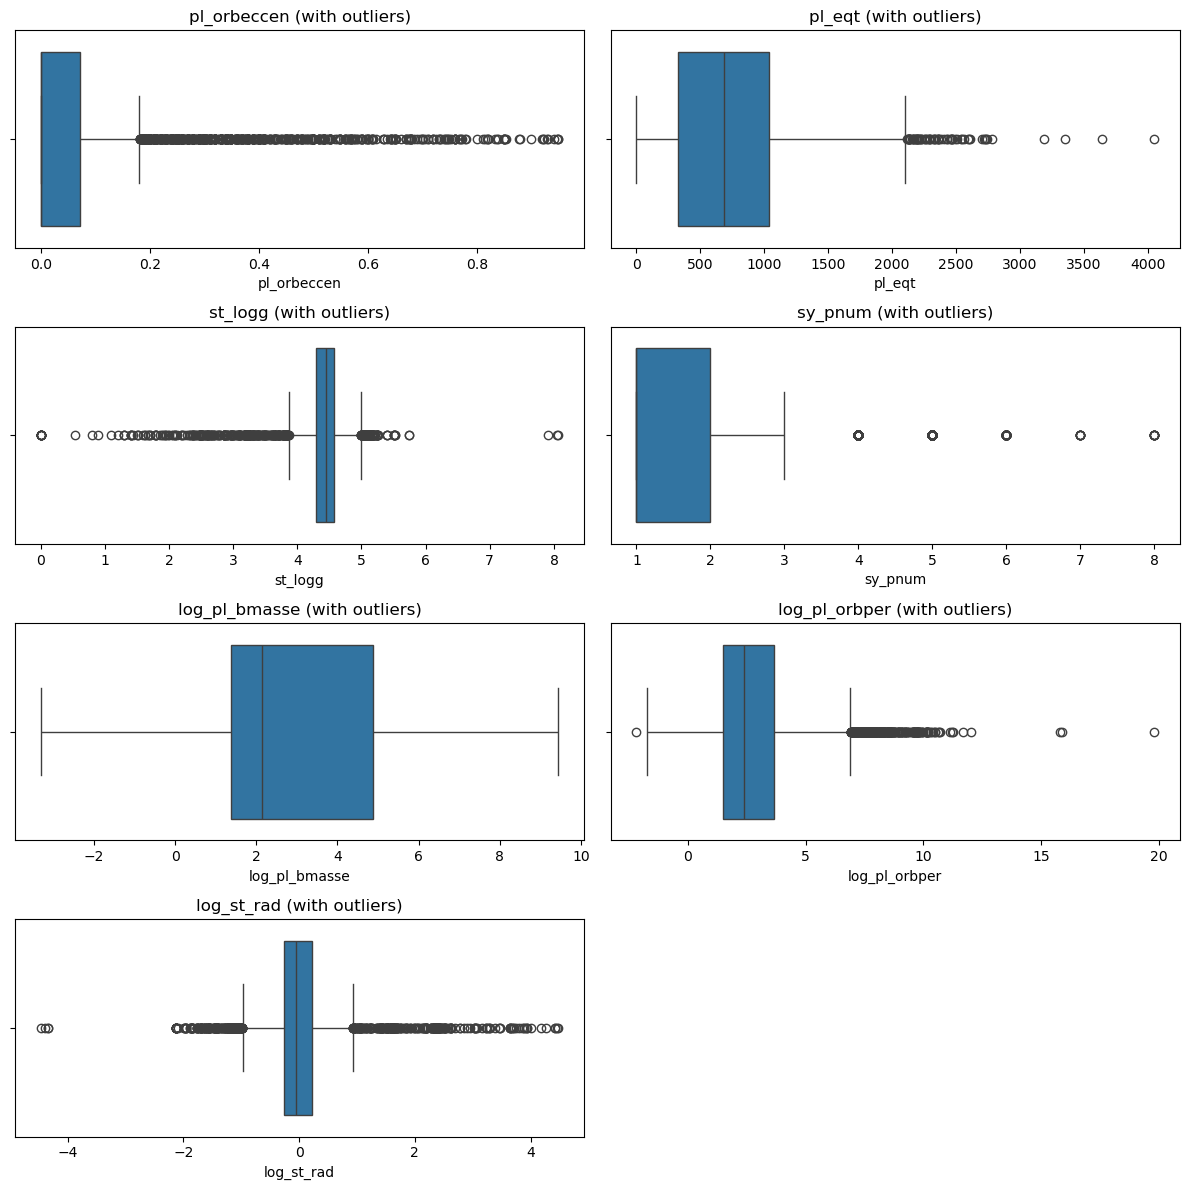

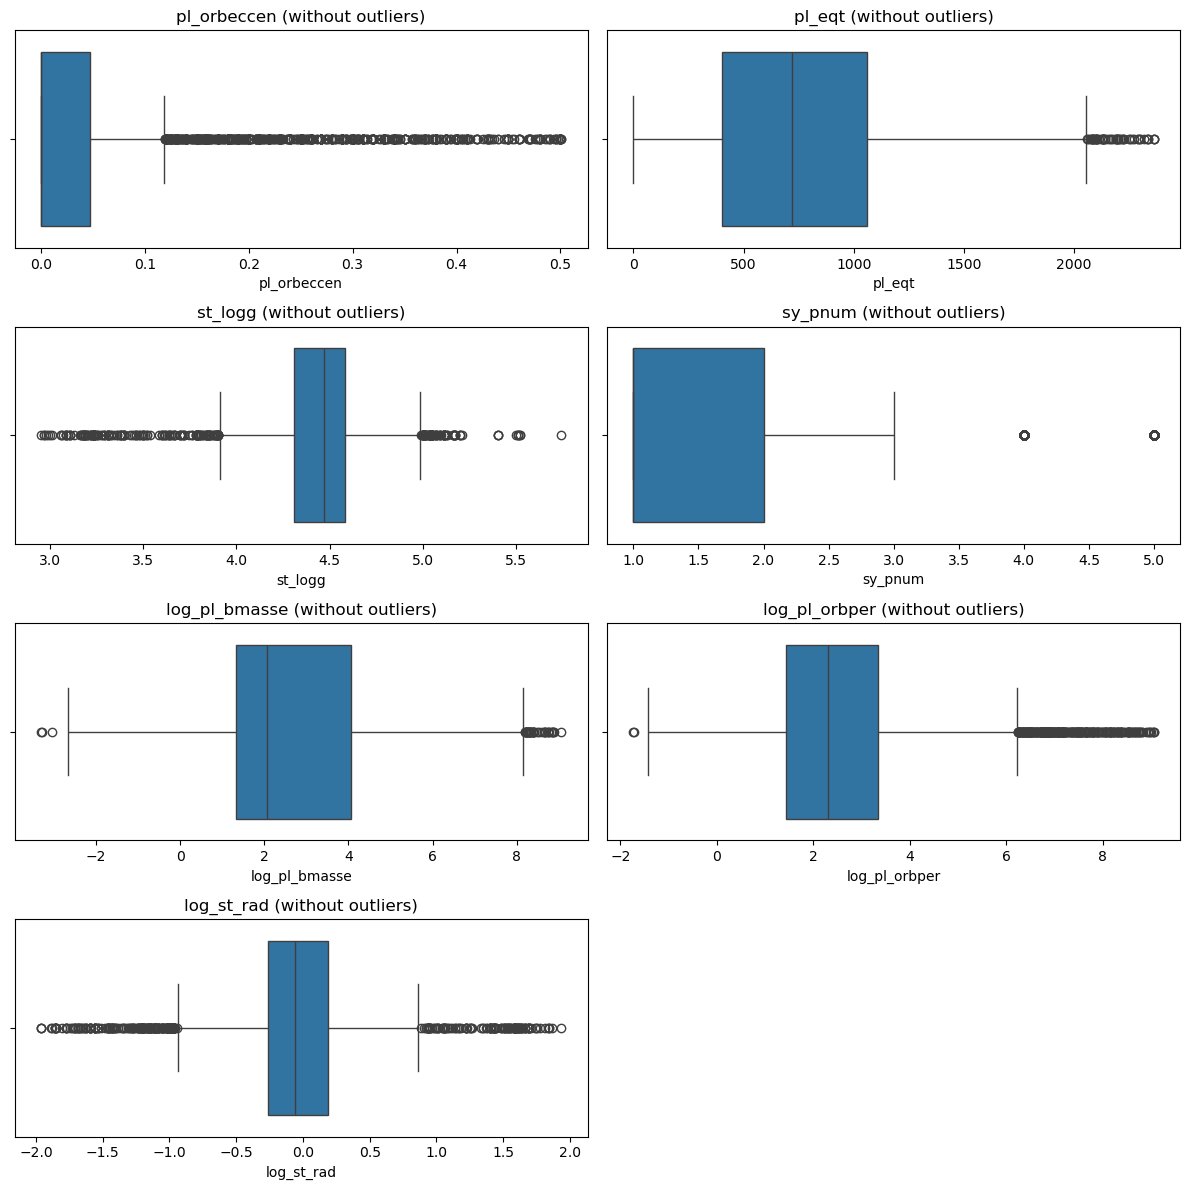


=== WITH outliers: overall accuracy (train/test) ===
SVM   train: 0.901, test: 0.882
Tree  train: 0.920, test: 0.916

SVM accuracy on TEST outliers   : 0.890
Tree accuracy on TEST outliers  : 0.937

=== WITHOUT outliers: overall accuracy (train/test) ===
SVM   train: 0.903, test: 0.884
Tree  train: 0.916, test: 0.916


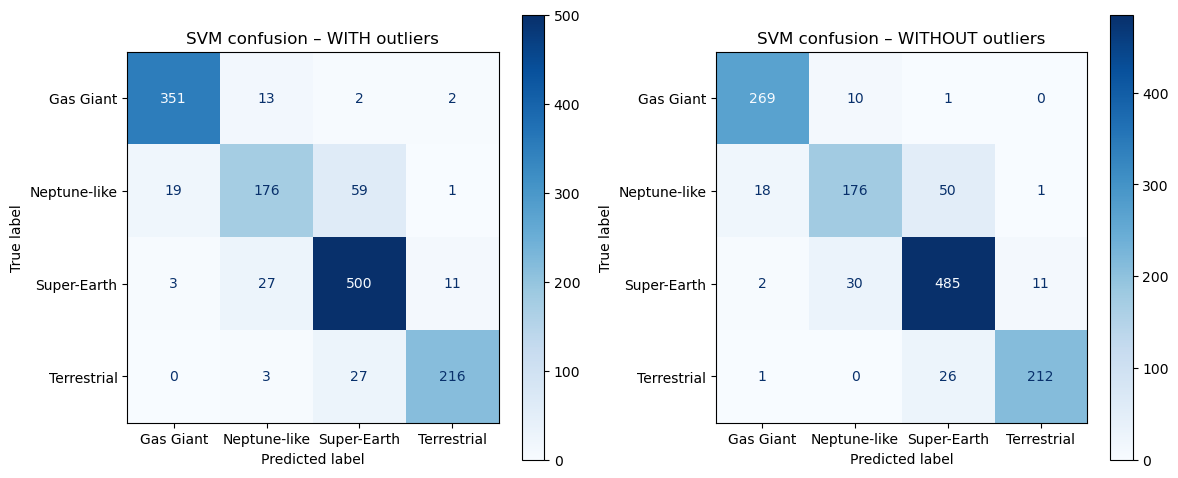

In [2]:
# Q6 – Outlier detection and model sensitivity (SVM vs Decision Tree)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------
# 0. Load data and prepare features (same as Q3/Q4)
# ---------------------------------------------------
df = pd.read_csv("exoplanet.csv")

for col in ["pl_bmasse", "pl_orbper", "st_rad"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace(0, np.nan)

df["log_pl_bmasse"] = np.log(df["pl_bmasse"])
df["log_pl_orbper"] = np.log(df["pl_orbper"])
df["log_st_rad"]    = np.log(df["st_rad"])

feature_cols = [
    "pl_orbeccen",
    "pl_eqt",
    "st_logg",
    "sy_pnum",
    "log_pl_bmasse",
    "log_pl_orbper",
    "log_st_rad",
]
target_col = "planet_class"

df_q6 = df[feature_cols + [target_col]].dropna().copy()
df_q6[feature_cols] = df_q6[feature_cols].fillna(df_q6[feature_cols].median())

print("Q6 dataset shape:", df_q6.shape)

X = df_q6[feature_cols].values
y = df_q6[target_col].astype(str).values

# ---------------------------------------------------
# 1. Outlier detection: z-score
# ---------------------------------------------------
# Z-score per feature, then check if any |z| > 3
z_scores = np.abs(stats.zscore(df_q6[feature_cols]))
out_mask = (z_scores > 3).any(axis=1)

df_q6["is_outlier"] = out_mask
n_outliers = df_q6["is_outlier"].sum()
print(f"\nDetected {n_outliers} outliers out of {len(df_q6)} samples.")

outliers = df_q6[df_q6["is_outlier"]]
clean_df = df_q6[~df_q6["is_outlier"]]

print("\nClass distribution among outliers:")
print(outliers[target_col].value_counts())

print("\nFirst 10 detected outliers (features + class):")
print(outliers[feature_cols + [target_col]].head(10))

print("\nZ-scores for first 10 outliers:")
print(pd.DataFrame(z_scores[df_q6["is_outlier"]], columns=feature_cols).head(10))

# ---------------------------------------------------
# 2. Visual inspection: boxplots with/without outliers
# ---------------------------------------------------
# --- Boxplots for each feature separately (WITH outliers) ---
plt.figure(figsize=(12, 12))
for i, col in enumerate(feature_cols):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=df_q6[col])
    plt.title(f"{col} (with outliers)")
plt.tight_layout()
plt.show()

# --- Boxplots for each feature separately (WITHOUT outliers) ---
plt.figure(figsize=(12, 12))
for i, col in enumerate(feature_cols):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=clean_df[col])
    plt.title(f"{col} (without outliers)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3. Train SVM & DT WITH outliers
#    (measure accuracy on test set and on test outliers)
# ---------------------------------------------------
X = df_q6[feature_cols].values
y = df_q6[target_col].astype(str).values
out_mask = df_q6["is_outlier"].values

X_train, X_test, y_train, y_test, out_train, out_test = train_test_split(
    X, y, out_mask, test_size=0.25, random_state=42, stratify=y
)

# SVM with scaling (RBF, best C/gamma from Q4)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=1000, gamma=0.01, random_state=42)
svm.fit(X_train_s, y_train)

# Decision Tree (best from Q5)
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
tree.fit(X_train, y_train)

# overall accuracy
svm_acc_train = svm.score(X_train_s, y_train)
svm_acc_test  = svm.score(X_test_s, y_test)

tree_acc_train = tree.score(X_train, y_train)
tree_acc_test  = tree.score(X_test, y_test)

# accuracy specifically on OUTLIERS in the TEST set
X_test_out_svm = X_test_s[out_test]
X_test_out_tree = X_test[out_test]
y_test_out = y_test[out_test]

svm_out_acc = accuracy_score(y_test_out, svm.predict(X_test_out_svm)) if len(y_test_out) > 0 else np.nan
tree_out_acc = accuracy_score(y_test_out, tree.predict(X_test_out_tree)) if len(y_test_out) > 0 else np.nan

print("\n=== WITH outliers: overall accuracy (train/test) ===")
print(f"SVM   train: {svm_acc_train:.3f}, test: {svm_acc_test:.3f}")
print(f"Tree  train: {tree_acc_train:.3f}, test: {tree_acc_test:.3f}")

print("\nSVM accuracy on TEST outliers   :", f"{svm_out_acc:.3f}" if not np.isnan(svm_out_acc) else "no outliers in test")
print("Tree accuracy on TEST outliers  :", f"{tree_out_acc:.3f}" if not np.isnan(tree_out_acc) else "no outliers in test")

# ---------------------------------------------------
# 4. Train SVM & DT WITHOUT outliers
# ---------------------------------------------------
X_clean = clean_df[feature_cols].values
y_clean = clean_df[target_col].astype(str).values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y_clean, test_size=0.25, random_state=42, stratify=y_clean
)

scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)

svm_clean = SVC(kernel="rbf", C=1000, gamma=0.01, random_state=42)
svm_clean.fit(Xc_train_s, yc_train)

tree_clean = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
tree_clean.fit(Xc_train, yc_train)

svm_clean_acc_train = svm_clean.score(Xc_train_s, yc_train)
svm_clean_acc_test  = svm_clean.score(Xc_test_s, yc_test)

tree_clean_acc_train = tree_clean.score(Xc_train, yc_train)
tree_clean_acc_test  = tree_clean.score(Xc_test, yc_test)

print("\n=== WITHOUT outliers: overall accuracy (train/test) ===")
print(f"SVM   train: {svm_clean_acc_train:.3f}, test: {svm_clean_acc_test:.3f}")
print(f"Tree  train: {tree_clean_acc_train:.3f}, test: {tree_clean_acc_test:.3f}")

# ---------------------------------------------------
# 5. Optional: confusion matrices for SVM (with vs without outliers)
# ---------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay

y_svm_test_pred = svm.predict(X_test_s)
y_svm_clean_test_pred = svm_clean.predict(Xc_test_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_svm_test_pred, ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("SVM confusion – WITH outliers")

ConfusionMatrixDisplay.from_predictions(
    yc_test, y_svm_clean_test_pred, ax=axes[1], cmap="Blues", values_format="d"
)
axes[1].set_title("SVM confusion – WITHOUT outliers")

plt.tight_layout()
plt.show()
